In [1]:
import os
import math
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

Experts shape: (9, 4)
Novices shape: (11, 4)

Statistical Summary:

    Group               Metric     Mean  Median  Variance  Skewness  Kurtosis
0  Expert           total time   65.116   70.12   158.474    -0.266     1.615
1  Novice           total time  107.073   98.08  1279.226     1.066     3.656
2  Expert  needle passing time   21.804   19.04    41.708     1.016     2.546
3  Novice  needle passing time   34.269   30.12   312.000     1.430     4.366
4  Expert      knot tying time   12.400   12.68    19.626     0.215     1.910
5  Novice      knot tying time   21.365   16.44    77.626     0.938     2.505


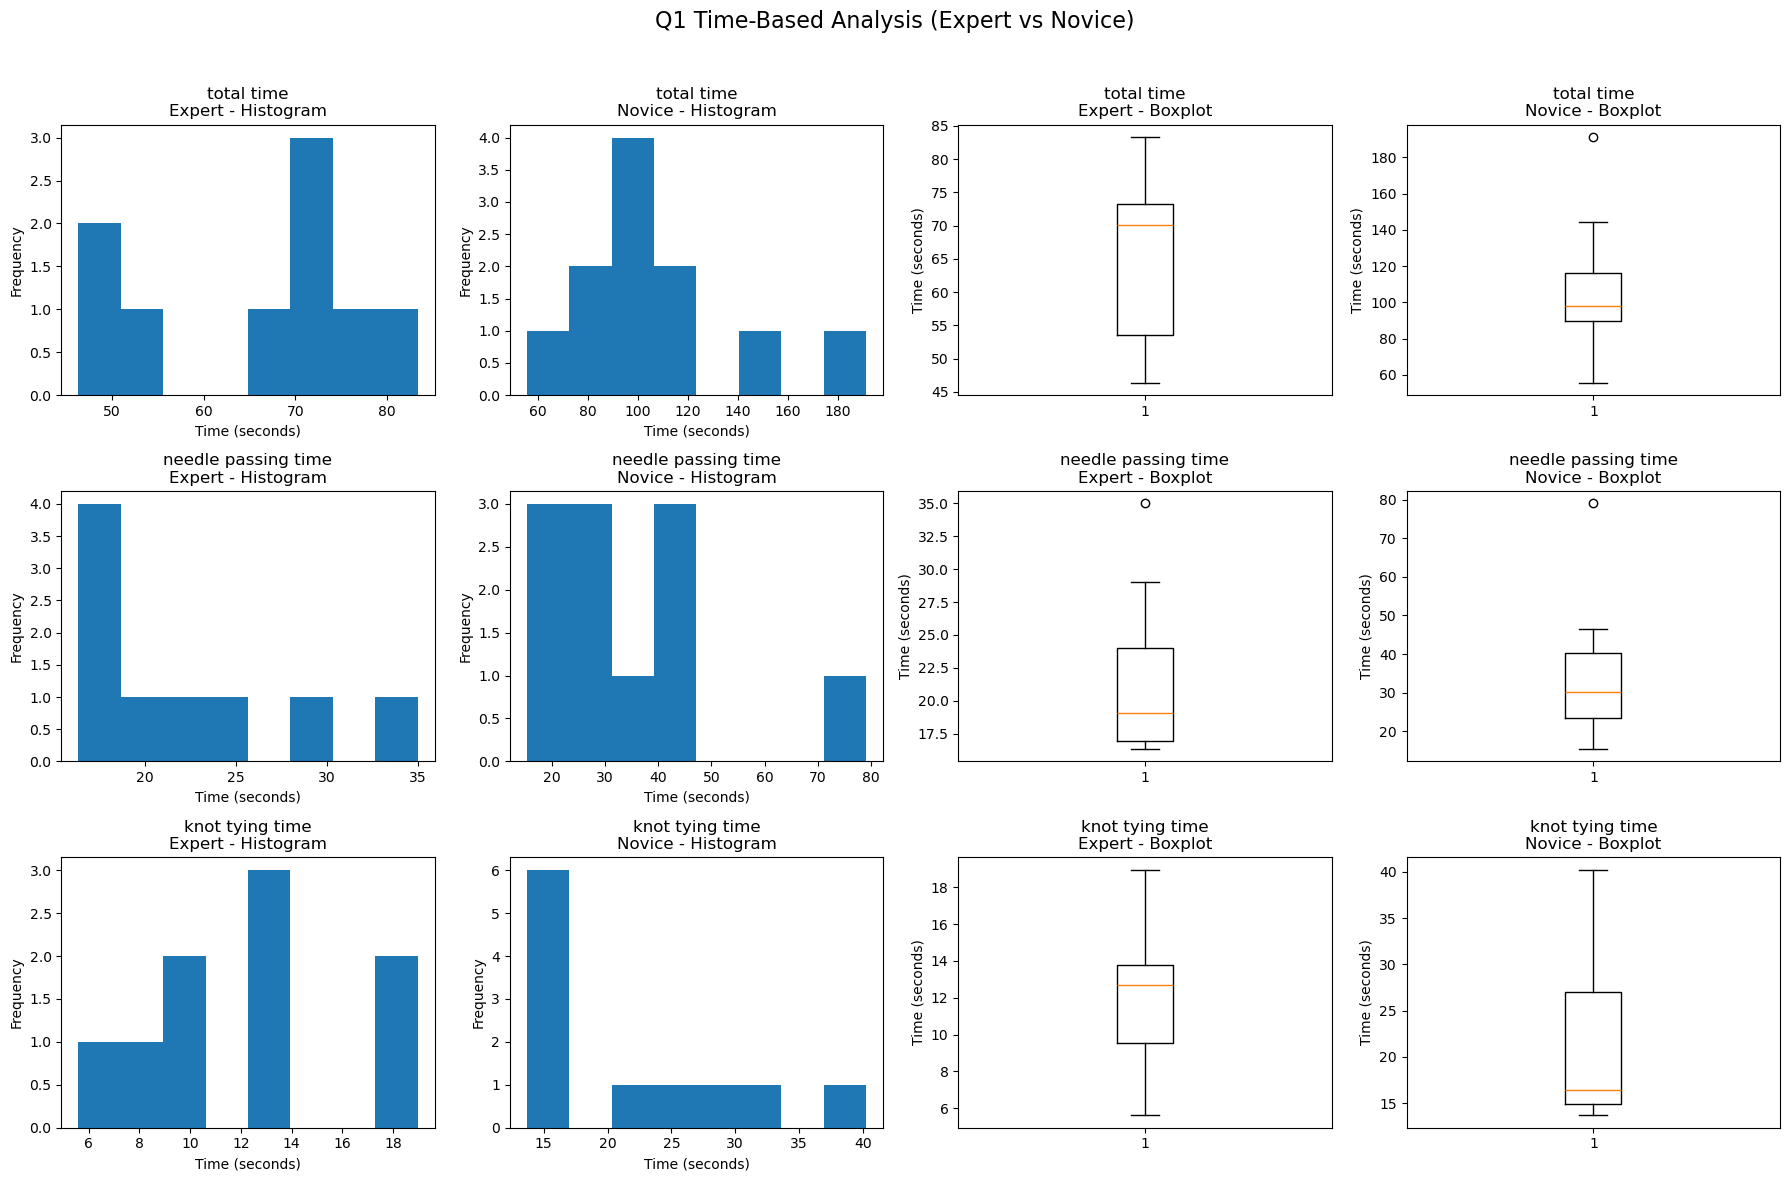

In [ ]:
# Question 1
COLUMNS = ['total time', 'needle passing time', 'knot tying time']

def mean(x):
    n = len(x)
    return sum(x) / n

def median(x):
    x_sorted = sorted(x)
    n = len(x_sorted)
    if n % 2 == 1:
        return x_sorted[n // 2]
    else:
        return (x_sorted[n // 2 - 1] + x_sorted[n // 2]) / 2

# Sample Variance (n-1)
def variance(x):
    n = len(x)
    mu = mean(x)
    return sum((v - mu) ** 2 for v in x) / (n - 1)

# Standard deviation
def std(x):
    return math.sqrt(variance(x))

# sum((x - mean)^3) / ((n-1) * s^3)
def skewness(x):
    n = len(x)
    mu = mean(x)
    sigma = std(x)

    if sigma == 0:
        return 0.0

    numerator = sum((v - mu) ** 3 for v in x)
    denominator = (n - 1) * (sigma ** 3)

    return numerator / denominator


# sum((x - mean)^4) / ((n-1) * s^4)
def kurtosis(x):
    n = len(x)
    mu = mean(x)
    sigma = std(x)

    if sigma == 0:
        return 0.0

    numerator = sum((v - mu) ** 4 for v in x)
    denominator = (n - 1) * (sigma ** 4)

    return numerator / denominator

def mannwhitney_test(group1, group2, alpha=0.05):
    u_stat, p_value = mannwhitneyu(group1, group2, alternative="two-sided")
    n1, n2 = len(group1), len(group2)
    rbc = 1 - (2 * u_stat) / (n1 * n2)

    return {
        "U": round(float(u_stat), 3),
        "p": round(float(p_value), 5),
        "significant": p_value < alpha,
        "effect_size_r": round(float(rbc), 3)
    }


experts = pd.read_csv('time_experts.csv')
novices = pd.read_csv('time_novices.csv')

print("Experts shape:", experts.shape)
print("Novices shape:", novices.shape)

results = []


# Compute Statistics
for col in COLUMNS:

    exp_vals = experts[col].astype(float).tolist()
    nov_vals = novices[col].astype(float).tolist()

    for group_name, values in [("Expert", exp_vals), ("Novice", nov_vals)]:
        results.append({
            "Group": group_name,
            "Metric": col,
            "Mean": round(mean(values), 3),
            "Median": round(median(values), 3),
            "Variance": round(variance(values), 3),
            "Skewness": round(skewness(values), 3),
            "Kurtosis": round(kurtosis(values), 3)
        })

stats_df = pd.DataFrame(results)

print("\nStatistical Summary:\n")
print(stats_df)


# Draw diagram
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Q1 Time-Based Analysis (Expert vs Novice)", fontsize=16)

for row, col in enumerate(COLUMNS):

    exp_vals = experts[col].astype(float).tolist()
    nov_vals = novices[col].astype(float).tolist()


    # Expert Histogram
    axes[row, 0].hist(exp_vals, bins=8)
    axes[row, 0].set_title(f"{col}\nExpert - Histogram")
    axes[row, 0].set_xlabel("Time (seconds)")
    axes[row, 0].set_ylabel("Frequency")


    # Novice Histogram
    axes[row, 1].hist(nov_vals, bins=8)
    axes[row, 1].set_title(f"{col}\nNovice - Histogram")
    axes[row, 1].set_xlabel("Time (seconds)")
    axes[row, 1].set_ylabel("Frequency")


    # Expert Boxplot
    axes[row, 2].boxplot(exp_vals, showfliers=True)
    axes[row, 2].set_title(f"{col}\nExpert - Boxplot")
    axes[row, 2].set_ylabel("Time (seconds)")

    # Novice Boxplot
    axes[row, 3].boxplot(nov_vals, showfliers=True)
    axes[row, 3].set_title(f"{col}\nNovice - Boxplot")
    axes[row, 3].set_ylabel("Time (seconds)")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("picture.png", dpi=300)
plt.show()

In [3]:
# Question 2

COLUMNS = [
    "total time",
    "needle passing time",
    "knot tying time"
]

experts = pd.read_csv("time_experts.csv")
novices = pd.read_csv("time_novices.csv")

results = []

print("\nQ2 – Mann–Whitney U Test Results")
print("-" * 40)


for col in COLUMNS:

    exp_vals = experts[col].astype(float)
    nov_vals = novices[col].astype(float)

    # Use unified function
    test_result = mannwhitney_test(exp_vals, nov_vals)


    results.append({
        "Metric": col,
        "U statistic": round(test_result["U"], 3),
        "p-value": round(test_result["p"], 5),
        "Significant": "Yes" if test_result["significant"] else "No",
        "Effect size (rank-biserial r)": round(test_result["effect_size_r"], 3)
    })

    # Interpretation
    print(f"\nFor {col}:")
    if test_result["significant"]:
        print(f"Significant difference detected (p = {test_result['p']:.4f}).")
    else:
        print(f"No statistically significant difference (p = {test_result['p']:.4f}).")


results_df = pd.DataFrame(results)
print(40*"-")

print("\nSummary Table:\n")
print(results_df)


Q2 – Mann–Whitney U Test Results
----------------------------------------

For total time:
Significant difference detected (p = 0.0011).

For needle passing time:
Significant difference detected (p = 0.0402).

For knot tying time:
Significant difference detected (p = 0.0062).
----------------------------------------

Summary Table:

                Metric  U statistic  p-value Significant  \
0           total time          6.0  0.00109         Yes   
1  needle passing time         22.0  0.04024         Yes   
2      knot tying time         13.0  0.00622         Yes   

   Effect size (rank-biserial r)  
0                          0.879  
1                          0.556  
2                          0.737  


In [4]:
# Question 3
ERROR_FILE = "error_data.xlsx"


# Error metric
def compute_error(seq_cells):
    seq = []

    for s in seq_cells:
        if pd.isna(s):
            continue
        if isinstance(s, str) and s.strip() == "-":
            continue

        try:
            v = int(s)
            if 1 <= v <= 5:
                seq.append(v)
        except ValueError:
            continue

    error = 0
    if 2 in seq:          # S2 present
        error += 1
    if 3 not in seq:      # S3 missing
        error += 1
    if 5 not in seq:      # S5 missing
        error += 1
    if seq.count(4) < 2:  # < 2 times S4
        error += 1

    return error


df = pd.read_excel(ERROR_FILE, header=0)


# Manual split, 2-11 = expert , 13-24 = novice
expert_df = df.iloc[0:9]
novice_df = df.iloc[11:22]

seq_cols = df.columns[1:7]

expert_errors = expert_df[seq_cols].apply(
    lambda r: compute_error(r.values), axis=1
)
novice_errors = novice_df[seq_cols].apply(
    lambda r: compute_error(r.values), axis=1
)


# Descriptive statistics
summary_df = pd.DataFrame([
    {
        "Group": "Expert",
        "N": len(expert_errors),
        "Mean error": round(expert_errors.mean(), 3),
        "Median error": round(expert_errors.median(), 3),
        "Variance": round(expert_errors.var(ddof=1), 3)
    },
    {
        "Group": "Novice",
        "N": len(novice_errors),
        "Mean error": round(novice_errors.mean(), 3),
        "Median error": round(novice_errors.median(), 3),
        "Variance": round(novice_errors.var(ddof=1), 3)
    }
])

test_result = mannwhitney_test(expert_errors, novice_errors)


test_df = pd.DataFrame([{
    "Test": "Mann–Whitney U",
    "U statistic": test_result["U"],
    "p-value": test_result["p"],
    "Significant (p < 0.05)": "Yes" if test_result["significant"] else "No",
    "Effect size (rank-biserial r)": test_result["effect_size_r"],
}])


# Print results
print("\nQ3 – Error Metric Analysis")

print("\nExpert errors:", list(expert_errors))
print("Novice errors:", list(novice_errors))

print("\nDescriptive Statistics:\n")
print(summary_df)

print("\nStatistical Test Result:\n")

print(f"{'Test':<20}{'U':<10}{'p-value':<12}{'Sig':<10}{'Effect r':<10}")
print("-" * 60)
print(f"{'Mann–Whitney U':<20}"
      f"{test_result['U']:<10.3f}"
      f"{test_result['p']:<12.5f}"
      f"{('Yes' if test_result['significant'] else 'No'):<10}"
      f"{test_result['effect_size_r']:<10.3f}")


Q3 – Error Metric Analysis

Expert errors: [1, 0, 1, 1, 1, 0, 1, 1, 2]
Novice errors: [0, 0, 1, 2, 1, 0, 1, 2, 1, 1, 0]

Descriptive Statistics:

    Group   N  Mean error  Median error  Variance
0  Expert   9       0.889           1.0     0.361
1  Novice  11       0.818           1.0     0.564

Statistical Test Result:

Test                U         p-value     Sig       Effect r  
------------------------------------------------------------
Mann–Whitney U      53.000    0.79950     No        -0.071    


In [5]:
# Question 4

# Paths
HEATMAP_DIR = Path("fixation_maps")
EXPERT_DIR = HEATMAP_DIR / "experts"
NOVICE_DIR = HEATMAP_DIR / "novice"

# Image resolution
IMG_WIDTH = 1920
IMG_HEIGHT = 1080
TOTAL_PIXELS = IMG_WIDTH * IMG_HEIGHT


def compute_fixation_sparsity(img_path: Path) -> float:
    """
    Fixation sparsity =
    (# non-white pixels) / (total pixels)
    """
    img = Image.open(img_path).convert("L")  # grayscale
    arr = np.array(img)
    non_white = np.sum(arr < 255)  # white pixels = 255
    return non_white / TOTAL_PIXELS


def load_group_sparsity(folder: Path):
    values = []
    if not folder.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")

    for img_path in folder.rglob("*"):
        if img_path.suffix.lower() not in {".png", ".jpg", ".jpeg", ".bmp"}:
            continue
        try:
            values.append(compute_fixation_sparsity(img_path))
        except Exception as e:
            print(f"Skip {img_path}: {e}")

    return values



# sparsity
expert_sparsity = load_group_sparsity(EXPERT_DIR)
novice_sparsity = load_group_sparsity(NOVICE_DIR)

if len(expert_sparsity) == 0 or len(novice_sparsity) == 0:
    raise RuntimeError(
        "One of the groups has zero samples. "
        "Please check fixation_maps/experts and fixation_maps/novice."
    )

# descriptive
summary_df = pd.DataFrame([
    {
        "Group": "Expert",
        "N": len(expert_sparsity),
        "Mean sparsity": round(float(np.mean(expert_sparsity)), 6),
        "Median sparsity": round(float(np.median(expert_sparsity)), 6),
        "Variance": round(float(np.var(expert_sparsity, ddof=1)), 6),
    },
    {
        "Group": "Novice",
        "N": len(novice_sparsity),
        "Mean sparsity": round(float(np.mean(novice_sparsity)), 6),
        "Median sparsity": round(float(np.median(novice_sparsity)), 6),
        "Variance": round(float(np.var(novice_sparsity, ddof=1)), 6),
    }
])

# Mann–Whitney U test 
test_result = mannwhitney_test(expert_sparsity, novice_sparsity)


test_df = pd.DataFrame([{
    "Metric": "Fixation sparsity",
    "Test": "Mann–Whitney U",
    "U_statistic": test_result["U"],
    "p-value": test_result["p"],
    "Significant": "Yes" if test_result["significant"] else "No",
    "Effect size": test_result["effect_size_r"],
}])

print("\nQ4 – Fixation Sparsity Analysis")
print("-" * 40)

print("\nDescriptive Statistics:\n")
print(summary_df.to_string(index=False))

print("\nStatistical Test Result:\n")
print(test_df.to_string(index=False))


Q4 – Fixation Sparsity Analysis
----------------------------------------

Descriptive Statistics:

 Group  N  Mean sparsity  Median sparsity  Variance
Expert  9       0.034369         0.036234  0.000066
Novice 11       0.052333         0.051644  0.000195

Statistical Test Result:

           Metric           Test  U_statistic  p-value Significant  Effect size
Fixation sparsity Mann–Whitney U         14.0  0.00784         Yes        0.717
